In [1]:
import copy
import os
from random import choices
import os.path as pth
from math import isnan
import platform
import subprocess
import numpy as np
import scipy.optimize as sp
import matplotlib.pyplot as plt
from time import time
from itertools import combinations
from math import comb

xfoil_path = "D:\\КММ_учеба\\01 Предметы\\7. ОПД\\XFoil\\xfoil.exe"


In [2]:
def curve_nd_order(a, b, c_points, n, t):
    if n == 2:
        m = a + (c_points[0]-a)*t
        n = c_points[0] + (b-c_points[0])*t
        return m + (n-m)*t
    else:
        m = curve_nd_order(a, b, c_points[0:n-2], n-1, t)
        n = curve_nd_order(a, b, c_points[1:n-1], n-1, t)
        return m+(n-m)*t

In [3]:
def curve(ax, ay, bx, by, cx_points, cyu_points, cyl_points, N, deg):
    x_axis, yu_axis, yl_axis  = [], [], []
    for i in range((N+1 - (N+1)//3), N+1):
        t = 0.5 + 0.5*np.cos(np.pi*(2.0*float(i) + 1.0)/(float(N+1)*2.0))
        x_axis.append(curve_nd_order(ax, bx, cx_points, deg, t))
        yu_axis.append(curve_nd_order(ay, by, cyu_points, deg, t))
        yl_axis.append(curve_nd_order(ay, by, cyl_points, deg, t))
    number = (N+2 - (N+1)//3)
    k = (N+1 - (N+1)//3)
    t = 0.5 + 0.5*np.cos(np.pi*(2.0*float(k) + 1.0)/(float(N+1)*2.0))
    h = (1.0 - t)/number
    x_axis = list(reversed(x_axis))
    yu_axis = list(reversed(yu_axis))
    yl_axis = list(reversed(yl_axis))
    for i in range(number-1):
        t += h
        x_axis.append(curve_nd_order(ax, bx, cx_points, deg, t))
        yu_axis.append(curve_nd_order(ay, by, cyu_points, deg, t))
        yl_axis.append(curve_nd_order(ay, by, cyl_points, deg, t))
    coords = []
    coords.append(list(reversed(x_axis[:])) + x_axis)
    coords.append(list(reversed(yl_axis[:])) + yu_axis)
    return coords

In [4]:
def writefile(name, coords):
    length = len(coords[0])
    with open(name, "w") as f:
        for i in range(length):
            f.write(str(coords[0][i]) + " " + str(coords[1][i]) + "\n" )

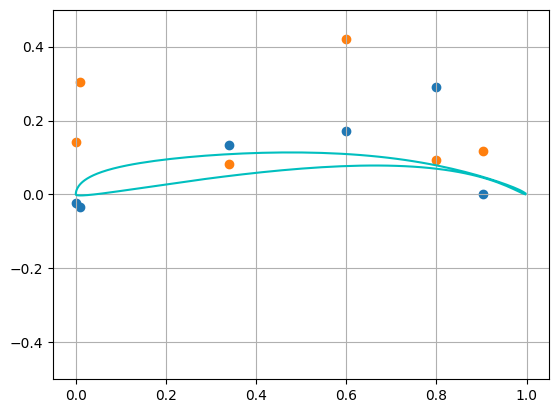

In [9]:
px1 = [0.13, 0.32, 0.6, 0.8, 0.9]
py1 = [0.215, 0.216, 0.23, 0.18, -0.035, 0.09]
qy1 = [-0.1, -0.21, -0.068, -0.18, 0.035, -0.07]

px = [0.1, 0.30, 0.6, 0.8, 1.0]
py = [0.25, 0.3, 0.2, 0.0, 0.02]
qy = [-0.106, -0.28, -0.1, -0.05, -0.01]


px3 = [0.15, 0.32, 0.6, 0.8, 0.9]
py3 = [-0.11200318, 0.01210229, 0.05873861, 0.29846013, 0.1100635]
qy3 = [0.38190633, 0.4607554, 0.4526208, 0.09432811, 0.21223437]

px4 = [0.15, 0.32, 0.6,  0.8,  0.9]
py4 = [-0.17685708, -0.01412248, -0.16502327, 0.2545887, 0.00129665]
qy4 = [0.25515416,  0.3613079, 0.37641853, -0.03741787, 0.12838295]

px5 = [0.06452765, 0.32, 0.6, 0.8, 0.9]
py5 = [0.35052449, 0.4607554,  0.4526208,  0.09432811, 0.21223437]
qy5 = [-0.08773221,  0.01210229,  0.05873861,  0.29846013,  0.1100635]

#142
px6 = [0.14013978097947924, 0.3100571124919583, 0.5892624173424218, 0.7891585701101465, 0.8890054007818506]
py6 = [-0.12352372355091917, -0.023141953436123443, 0.04868273668194764, 0.2885564796321478, -0.008171807177437637]
qy6 = [0.3920969824512014, 0.3722605757643568, 0.46283321838309543, 0.10468813273466378, 0.13866632326895773]
#148.89
px7 = [0.0, 0.34494435606175755, 0.600286774327103, 0.7996433126669729, 0.8992351220854146]
py7 = [-0.13410590595092683, -0.05636195376711043, 0.03772992081400767, 0.2792664316756642, -0.01660145160012467]
qy7 = [0.3832092298295305, 0.33756073633713, 0.4518166630372508, 0.09430456556792816, 0.12830842678721954]

#0.1501097730829904
px8 = [0.0, 0.0009892112544482316, 0.3514440261637464, 0.5990504129260643, 0.7980429555981524, 0.9013737553584837]
py8 = [-0.09969865413095004, -0.13191086976153588, -0.05620044563477127, 0.03997132612052514, 0.2884622964036485, -0.007029504306061872]
qy8 = [0.20755452537835478, 0.37728118271936373, 0.3332461588730202, 0.449858656452017, 0.09303066738282113, 0.11849975318877949]

px9 = [0.0, 0.009243865544772818, 0.33953559446396414, 0.5990978360501522, 0.7988101483092795, 0.9026885133327629]
py9 = [-0.023887276658437026, -0.0328203287850881, 0.13325839647316756, 0.17122405107284883, 0.2899193079925572, 0.0018756991067779077]
qy9 = [0.14298975245153414, 0.30559522023606855, 0.08212527159427359, 0.4203603799296552, 0.09326239174304628, 0.11848792998986313]

px10 = [0.0, 0.002952029323103665, 0.34441059952907777, 0.600426863096378, 0.7943404027810738, 0.8998367446385636]
py10 = [-0.09819758864458229, -0.13268823391782794, -0.056531774597046815, 0.04394266314452003, 0.2903813127389635, 0.0006978628887499485]
qy10 = [0.20209392726940242, 0.31112461650147766, 0.2892773167623976, 0.47826563654740323, 0.09303066738282113, 0.11849975318877949]
px12 = [0.0, 0.006201667533459583, 0.34069647412061727, 0.6008486451725575, 0.7991770984226978, 0.8981601704818134]
py12 = [-0.0963826948070401, -0.12824861761178538, -0.055235873650895426, 0.049353987896435435, 0.2899193079925572, 0.0018756991067779077]
qy12 = [0.1429254716767246, 0.3054711841961071, 0.08176816067369239, 0.4202827713824092, 0.09303066738282113, 0.11849975318877949]

px13 = [0.0, 0.009243865544772818, 0.33953559446396414, 0.5990978360501522, 0.7988101483092795, 0.9026885133327629]
py13 = [-0.023887276658437026, -0.0328203287850881, 0.13325839647316756, 0.17122405107284883, 0.2899193079925572, 0.0018756991067779077]
qy13 = [0.14298975245153414, 0.30559522023606855, 0.08212527159427359, 0.4203603799296552, 0.09326239174304628, 0.11848792998986313]

px14 = [0.0, 0.09724684, 0.44235462, 0.91797033, 0.99776263, 0.29228509]
py14 = [0.09021322, 0.1768766, 0.24778415, 0.39011043, -0.02319532, 0.15824607]
qy14 = [-0.16038702, 0.00179558, -0.03724574, -0.11454308, 0.02882499, -0.05366433]


with open("airfoil.txt") as f:
    x, yb, yn = [], [], []
    coords_e = []
    cords = []
    for i in f:
        enter = i.split()
        x.append(float(enter[0]))
        yb.append(float(enter[1]))
        #yn.append(float(enter[2]))
    #coords_e.append(list(reversed(x)) + x)
    #coords_e.append(list(reversed(yn)) + yb)
    coords_e.append(x)
    coords_e.append(yb)
    x = []
    y = []
    for i in range(101):
        x.append(0.5*np.cos(2*np.pi*i/100)+ 0.5)
        y.append(0.5*np.sin(2*np.pi*i/100))
    cords.append(x)
    cords.append(y)
cx_points = np.array(px, float)
cyu_points = np.array(py1, float)
cyl_points = np.array(qy1, float)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.5, 0.5)
#plt.xlim(-0.01, .001)
#plt.ylim(-0.0005, 0.0005)
plt.grid()

N = 80
#result = np.genfromtxt('result.txt', skip_header=12)
#ko = result[2]/result[1]
#print(ko)
#plt.plot(coords_e[0], coords_e[1])

px2 = [0.0, 0.14, 0.33, 0.6, 0.8, 0.9 ]
py2 = [-0.13, -0.3, -0.1, -0.001, -0.0, 0.0]
qy2 = [0.4, 0.30, 0.30, 0.1626208,  0.09432811, -0.001223437]

#coords1 = curve(0.0, 0.0, 1.0, 0.0, np.array(px2, float), np.array(py2, float), np.array(qy2, float), N, 7)
coords2 = curve(0.0, 0.0, 1.0, 0.0, np.array(px13, float), np.array(py13, float), np.array(qy13, float), N, 7)
plt.plot(coords2[0], coords2[1], "c")
plt.scatter(np.array(px13, float), np.array(py13, float))
plt.scatter(np.array(px13, float), np.array(qy13, float))
#plt.xlabel("Gen number")
#plt.ylabel("Сl/Cd", rotation=0)
#plt.title("Convergence history")
#coordsx = [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],[17.64, 101.19, 120.9, 130.36, 142.2, 145.9, 146.48, 148.8, 164.4, 180.64, 217.17]]
#plt.scatter(coordsx[0], coordsx[1])
#plt.plot(coords1[0], coords1[1], "c")
#writefile("x0.txt", coords1)
#writefile("tsagi.txt", coords_e)
#writefile("217.txt", coords1)
#plt.plot(cords[0], cords[1])

Вызов XFoil

In [6]:
def dfile(name):
    if os.path.exists(name):
        os.remove(name)
    return None

def k(x):
    N = 50
    deg= 7

    cx_points = [0.0, abs(x[0]), abs(x[1]), abs(x[2]), abs(x[3]), abs(x[4])]
    cx_points.sort()
    cyu_points = [x[5], x[6], x[7], x[8], x[9], x[10]]
    cyl_points  = [x[11], x[12], x[13], x[14], x[15], x[16]]
    airfoil=curve(0.0, 0.0, 1.0, 0.0, cx_points, cyu_points, cyl_points, N, deg)
    #airfoil=np.transpose(airfoil)
    #np.savetxt('test.dat', airfoil)
    writefile("airfoil.txt", airfoil)
    dfile('outlog.log')
    dfile('result.txt')
    try:
        with open("input.txt") as session_inputs:
	        with open("outlog.log", "w") as session_outputs:
		        subprocess.run([xfoil_path], stdin=session_inputs, stdout=session_outputs, timeout = 1.5)

        result = np.genfromtxt('result.txt', skip_header=12)
        ko = result[2]/result[1]
        if ko < 0:
            ko = 1e+14
    except:
        ko = 1e+14
    f = open("history_k.txt", "a")
    f.write(format(1.0/ko))
    f.write('\n')
    f.close()
    g = open("history_x.txt", "a")
    g.write(format(x))
    g.write('\n')
    g.close()
    return ko

bnds = ((0.,1.), (0.,1.), (0.,1.), (0.,1.), (0.,1.), (-1.,3.),(-1.,3.),(-1.,3.), (-1.,3.), (-1.,3.), (-1.,3.), (-3.,1.),(-3.,1.),(-3.,1.), (-3.,1.), (-3.,1.), (-3.,1.))
X0 = np.array(px1 + py1 + qy1, float)
print(np.shape(X0))
#print(k(X0))
X0=np.random.normal(0.00, 0.025, 17) + X0
#res = sp.differential_evolution(k, bnds, x0 = X0)

res = sp.minimize(k, X0, method='Nelder-Mead', options={'gtol': 1e-6, 'disp': True})
#res = sp.shgo(k, bnds)
#print(res)


(17,)


C:\Users\huawei\AppData\Local\Temp\ipykernel_22204\2318767356.py:48: OptimizeWarning: Unknown solver options: gtol
  res = sp.minimize(k, X0, method='Nelder-Mead', options={'gtol': 1e-6, 'disp': True})


Optimization terminated successfully.
         Current function value: 0.011521
         Iterations: 315
         Function evaluations: 657


Генетический алгоритм оптимизации

In [24]:
px3 = [0.15, 0.32, 0.6, 0.8, 0.9]
py3 = [-0.11200318, 0.01210229, 0.05873861, 0.29846013, 0.1100635]
qy3 = [0.38190633, 0.4607554, 0.4526208, 0.09432811, 0.21223437]

px4 = [0.15, 0.32, 0.6,  0.8,  0.9]
py4 = [-0.17685708, -0.01412248, -0.16502327, 0.2545887, 0.00129665]
qy4 = [0.25515416,  0.3613079, 0.37641853, -0.03741787, 0.12838295]

#142
px6 = [0.14013978097947924, 0.3100571124919583, 0.5892624173424218, 0.7891585701101465, 0.8890054007818506]
py6 = [-0.12352372355091917, -0.023141953436123443, 0.04868273668194764, 0.2885564796321478, -0.008171807177437637]
qy6 = [0.3920969824512014, 0.3722605757643568, 0.46283321838309543, 0.10468813273466378, 0.13866632326895773]
#145.9
px9 = [0.0, 0.0, 0.34494435606175755, 0.600286774327103, 0.7996433126669729, 0.8992351220854146]
py9 = [-0.2, -0.13410590595092683, -0.05636195376711043, 0.03772992081400767, 0.2792664316756642, -0.01660145160012467]
qy9 = [0.3, 0.3832092298295305, 0.33756073633713, 0.4518166630372508, 0.09430456556792816, 0.12830842678721954]

px8 = [0.0, 0.0009892112544482316, 0.3514440261637464, 0.5990504129260643, 0.7980429555981524, 0.9013737553584837]
py8 = [-0.09969865413095004, -0.13191086976153588, -0.05620044563477127, 0.03997132612052514, 0.2884622964036485, -0.007029504306061872]
qy8 = [0.20755452537835478, 0.37728118271936373, 0.3332461588730202, 0.449858656452017, 0.09303066738282113, 0.11849975318877949]

#164.4
px10 = [0.0, 0.002952029323103665, 0.34441059952907777, 0.600426863096378, 0.7943404027810738, 0.8998367446385636]
py10 = [-0.09819758864458229, -0.13268823391782794, -0.056531774597046815, 0.04394266314452003, 0.2903813127389635, 0.0006978628887499485]
qy10 = [0.20209392726940242, 0.31112461650147766, 0.2892773167623976, 0.47826563654740323, 0.09303066738282113, 0.11849975318877949]
#164.3120393120393
px11 = [0.0, 0.002334635289160968, 0.3420237637550309, 0.6030511540639976, 0.794427603958646, 0.9015146712036455]
py11 = [-0.09450786316482977, -0.1349728232659944, -0.05399900555959206, 0.045070422546365736, 0.28988753404966844, 0.0008203460207934356]
qy11 = [0.2237141647696984, 0.31591035309548815, 0.29145666889301486, 0.4702265089457169, 0.09303066738282113, 0.11849975318877949]

#180.64318529862175
px12 = [0.0, 0.006201667533459583, 0.34069647412061727, 0.6008486451725575, 0.7991770984226978, 0.8981601704818134]
py12 = [-0.0963826948070401, -0.12824861761178538, -0.055235873650895426, 0.049353987896435435, 0.2899193079925572, 0.0018756991067779077]
qy12 = [0.1429254716767246, 0.3054711841961071, 0.08176816067369239, 0.4202827713824092, 0.09303066738282113, 0.11849975318877949]
#179.96941896024467
px13 = [0.0, 0.006201667533459583, 0.34069647412061727, 0.6008486451725575, 0.7991770984226978, 0.8981601704818134]
py13 = [-0.0963826948070401, -0.12824861761178538, -0.055235873650895426, 0.049353987896435435, 0.2899193079925572, 0.0018756991067779077]
qy13 = [0.1429254716767246, 0.3054711841961071, 0.08176816067369239, 0.4202827713824092, 0.09303066738282113, 0.11849975318877949]

print(np.random.normal(0.00, 0.01, 3))
parent = list([[px12, py12, qy12], [px13, py13, qy13]]) #Родители n1

def genetic2(n1, gen, parents):
    def getpot(par, n):
        #print(par)
        return crossover(par[0], par[1], n)

    def otbor(children): #Отбор 2 лучших родителей
        kat = []
        best_k = []
        for i in children:
            kat.append(k(i[0], i[1], i[2]))
        index = kat.index(min(kat))
        best_k.append(children[index])
        print(1.0/kat[index], children[index])
        kat.pop(index)
        index = kat.index(min(kat))
        best_k.append(children[index])
        print(1.0/kat[index], children[index])
        kat.pop(index)
        return best_k


    def crossover(par1, par2, n):
        #0 - x, 1 - yl, 2 - yu. Родители - кортежи из трех хромосом
        #Генерация векторов смещений '2' - '1'
        h = []
        for i in range(3):
            h.append(list(np.array(par2[i]) - np.array((par1[i]))))

        #print(h)
        variants = list(range(n)) # Числа от 1 до n- номера координат для выбора
        children = [] # 1 ребенок - совокупность трех хромосом
        count = 0
        for i in range(1, n-1):
            for j in list(combinations(variants, i)):
                count+=1
                #Создаем 3 хромосомы.
                buff = copy.deepcopy(par1)
                #print("buff", buff1)
                for k1 in j:
                    #print(buff[0][int(k)])
                    buff[0][k1] = buff[0][k1] + h[0][k1]
                    #print(buff[0])
                    buff[0] = list(np.array(buff[0]) + np.random.normal(0.00, 0.001, n)) if choices([-1, 1], weights=[75, 25]) else buff[0]
                    buff[0] = list(np.abs(np.array(buff[0])))
                    buff[0].sort() #ГМО
                    mut = np.random.normal(0.005, 0.05, n)
                    mut[4:n] = 0.0
                    buff[1][k1] = buff[1][k1] + h[1][k1]
                    buff[1] = list(np.array(buff[1]) + mut) if choices([-1, 1], weights=[75, 25]) else buff[1]
                    buff[2][k1] = buff[2][k1] +  h[2][k1]
                    buff[2] = list(np.array(buff[2]) + np.random.normal(0.00, 0.0001, n)) if choices([-1, 1], weights=[75, 25]) else buff[2]

                children.append(buff)

        print(count)
        return children
    new_parents = parents.copy()
    for i in range(gen):
    #child = list(getpot(new_parents, n1))
        child = list(crossover(new_parents[0], new_parents[1], 6))
        child.append(new_parents[0])
        child.append(new_parents[1])
        new_parents = list(otbor(child))
    return None

#buff = (0, 1, 2, 3)
#print(parent)
#print(genetic2(6, 5, parent.copy()))

[-0.00530878  0.01027914  0.00647224]
